In [1]:
import pathlib


import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

import seaborn as sns

In [2]:
xlsx_dir = pathlib.Path("../data/xlsx")
figs_dir = pathlib.Path("../data/misc")

In [3]:
parents = ["1-VH", "2-L", "3-VRL", "2-D"]

### Load in screening data

In [4]:
# load in screening data
screen_d = {p:pd.read_excel(xlsx_dir / "2022-11-16 Screening data corrected.xlsx", 
                            usecols="A:P", sheet_name=i) for i, p in enumerate(parents)}

print("Number of rows in each sheet : ", 
          {k:len(v) for k, v in screen_d.items()})

print("Number of rows without sample: ",
     {k:v["Sample"].isna().sum() for k, v in screen_d.items()})

print("OPERATION: Removing NA samples...")
screen_d = {k:v[~v["Sample"].isna()] for k, v in screen_d.items()}

print("OPERATION: Adding plate_row_col columns...")
for k, v in screen_d.items():
    v["plate_row_col"] = v["Plate"].astype(int).astype(str).str.zfill(2) + "-" + \
                         v["Row"] + "-" + \
                         v["Column"].astype(int).astype(str).str.zfill(2)

#print("OPERATION: Only keeping variant == 1")
#for k, v in screen_d.items():
#    screen_d[k] = v[v["Variant?"].astype(str) == "1"].copy()
    
#print("Number of rows in each bin : ", 
#          {k:len(v) for k, v in screen_d.items()})    

Number of rows in each sheet :  {'1-VH': 864, '2-L': 962, '3-VRL': 960, '2-D': 960}
Number of rows without sample:  {'1-VH': 0, '2-L': 2, '3-VRL': 0, '2-D': 0}
OPERATION: Removing NA samples...
OPERATION: Adding plate_row_col columns...


### Load in bins data

In [5]:
bins_d = {p:pd.read_excel(xlsx_dir / "2022-11-21 Bins.xlsx", usecols="A:D",
                         sheet_name=i) for i, p in enumerate(parents)}
# melt all the bin dataframes
bins_d = {p:pd.melt(v, var_name="category", value_name="plate_row_col")
              for p, v in bins_d.items()}

# remove NA's from plate_row_cols
bins_d = {p:v[~v["plate_row_col"].isna()] for p, v in bins_d.items()}

def make_categorical_bins(series):
    make_categorical_bins.categories = ["High", "Parent", "Low", "No Activity"]
    make_categorical_bins.map_d = {x[0]:x for x in make_categorical_bins.categories}
    return pd.Categorical(series, 
                       categories=make_categorical_bins.categories,
                       ordered=True)

for k, v in bins_d.items():
    v["category"] = make_categorical_bins(v["category"])

In [6]:
def standardize_plate_row_col(s):
    """Take the string for plate_row_col and make it look like 05-A-11"""
    assert(s.count("-") == 1) # there should be exactly one - in it already
    sp = s.split("-")
    row = sp[0][-1]
    plate = int(sp[0][:-1])
    col = int(sp[1])
    return f"{plate:02d}-{row}-{col:02d}"

# standardize all the plate_row_col so they look like 05-A-11
for k, v in bins_d.items():
    v["plate_row_col"] = v["plate_row_col"].map(standardize_plate_row_col)

In [7]:
print("Number of rows: ",
     {k:len(v) for k, v in bins_d.items()})

Number of rows:  {'1-VH': 809, '2-L': 900, '3-VRL': 899, '2-D': 900}


In [8]:
# do an outer join
join_d = {}
for p in parents:
    join_d[p] = pd.merge(screen_d[p], bins_d[p], on=["plate_row_col"], how="outer")
    
for p in parents:
    assert(len(join_d[p][join_d[p]["Sample"].isna()][["plate_row_col", "category"]]) == 0)

In [9]:
for p in parents:
    print(p)
    print(join_d[p][join_d[p]["category"].isna() & (join_d[p]["Variant?"].astype(str) == "1")])

1-VH
Empty DataFrame
Columns: [Sample, Plate, Row, Column, #, Variant?, Area(S), Area(OH1), Area(OH2), Area(N3), %OH1, %OH2, %N3, N3/OH, %N3(plate parent), Std Dev, plate_row_col, category]
Index: []
2-L
Empty DataFrame
Columns: [Sample, Plate, Row, Column, #, Variant?, Area(S), Area(OH1), Area(OH2), Area(N3), %OH1, %OH2, %N3, N3/OH, %N3(plate parent), Std Dev, plate_row_col, category]
Index: []
3-VRL
               Sample  Plate Row  Column    # Variant?  Area(S)  Area(OH1)  \
87   3-VRL_01H-04_088      1   H       4   88        1   821208     5309.0   
183  3-VRL_02H-04_184      2   H       4  184        1   742543        NaN   
279  3-VRL_04H-04_280      3   H       4  280        1   264338        NaN   
375  3-VRL_04H-04_376      4   H       4  376        1   197832        NaN   
471  3-VRL_05H-04_472      5   H       4  472        1   445371      200.0   
567  3-VRL_06H-04_568      6   H       4  568        1   479990     1155.0   
663  3-VRL_07H-04_664      7   H       4  664    

In [19]:
# look at samples placed from merging the bin and screening data spreadsheets
counts = []
for p in parents:
    v = join_d[p][~join_d[p]["category"].isna()]
    vc = v["category"].value_counts()
    vc = pd.DataFrame(vc).reset_index()
    vc.columns = ["category", "count"]
    vc["parent"] = p
    counts.append(vc)    
pd.concat(counts).pivot_table(index=["parent"], columns=["category"],
                        aggfunc=sum, margins=True, margins_name="Sum")

count                               
category  High Parent   Low No Activity   Sum
parent                                       
1-VH         4      2   349         454   809
2-D         16     27   174         683   900
2-L         29     52   532         287   900
3-VRL       81    222   266         330   899
Sum        130    303  1321        1754  3508

In [18]:
# read in samples for 1-VH, 2-L and 3-VRL
samples = pd.read_csv("../data/scratch/Oct22/Samples.csv")[["sample", "num_placed"]]
samples[["parent", "category"]] = samples["sample"].str.split("_", expand=True)
samples["category"] = make_categorical_bins(samples.category.map(make_categorical_bins.map_d))
samples = samples[["num_placed", "parent", "category"]].copy()

# read in 2D data
samples_2D = pd.read_csv("../data/scratch/Oct22_2D/Samples.csv")[["sample", "num_placed"]]
samples_2D[["category", "activity"]] = samples_2D["sample"].str.split(" ", expand=True)
samples_2D["category"] = make_categorical_bins(samples_2D.category.str.get(0).map(make_categorical_bins.map_d))
samples_2D[["parent"]] = "2D"
samples_2D = samples_2D[samples_2D.activity.str.contains("Azidation")][["num_placed", "parent", "category"]]

# get number of samples placed
pd.concat([samples, samples_2D]).pivot_table(index=["parent"], columns=["category"], 
                                             aggfunc=sum, margins=True, margins_name="Sum")

num_placed                               
category       High Parent   Low No Activity   Sum
parent                                            
1VH               4      2   349         454   809
2D               16     27   174         683   900
2L               29     52   532         287   900
3VRL             81    222   266         330   899
Sum             130    303  1321        1754  3508

In [27]:
df = join_d["2-D"]
df = df[~df["category"].isna()].copy()

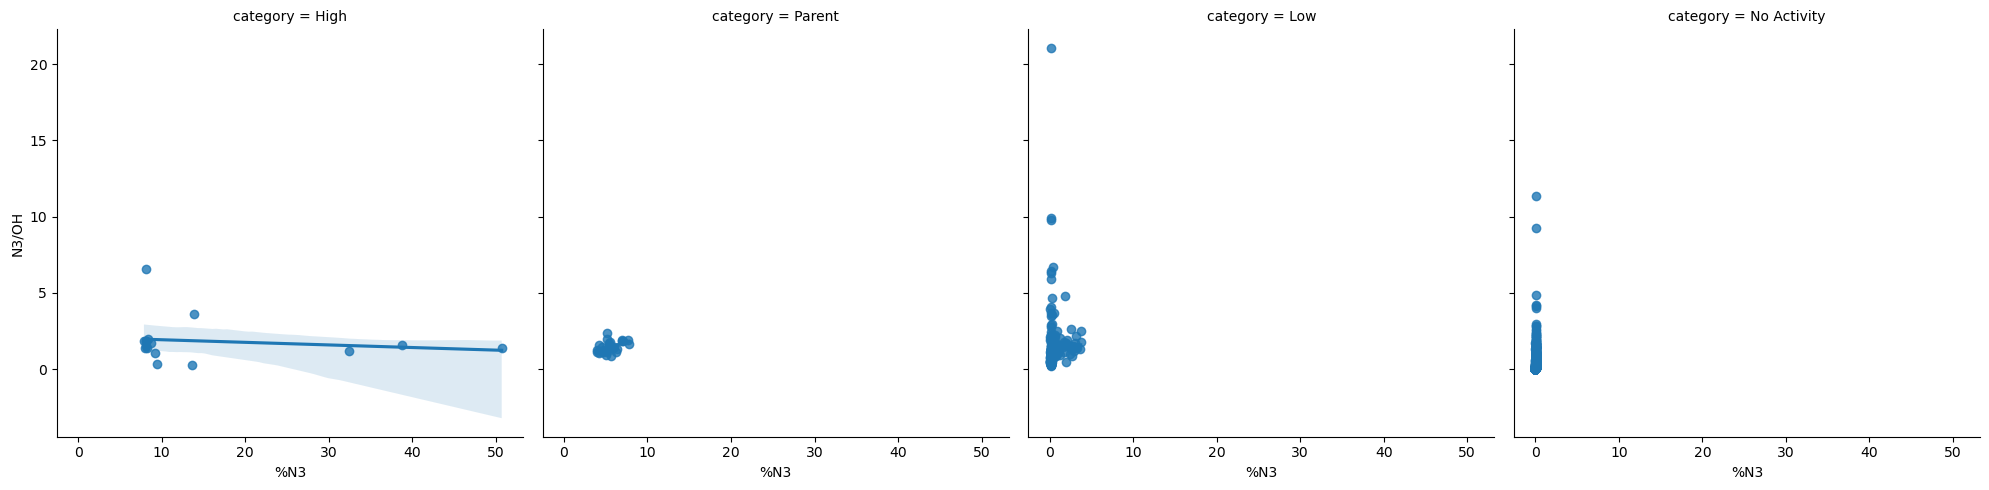

In [30]:
sns.lmplot(data=df, x="%N3", y="N3/OH", col="category")